# Example 2: Stream-Temperature Forecasting (Experiment 2)

Mirrors the paper's Experiment 2: HydroORBIT is retargeted, with no architecture change, to forecast
stream temperature instead of streamflow -- streamflow becomes an input covariate rather than the
prediction target, testing generalization to a variable never seen as a target during pretraining.

**Case study**: basin `01184000` (Connecticut River at Thompsonville, CT) -- selected as the
highest-median-NSE basin with full lead-time coverage in the paper's Experiment 3 (stream
temperature) evaluation. This notebook runs 30 forecast cycles spread across the 2025 evaluation
year and reports NSE **at each lead time**, pooled across those 30 cycles.

Data: `data/exp2_stream_temperature/01184000.csv` -- 2 years of hourly forcing + streamflow + water
temperature (`water_temp_C`); 2024 provides trailing context for origins issued during 2025.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from src.pipeline import HydroORBITPipeline

WEIGHTS_DIR = REPO_ROOT / "weights"
pipe = HydroORBITPipeline.from_pretrained(str(WEIGHTS_DIR))
print("Loaded HydroORBIT on device:", pipe.device)

FORCING_COLS = ["Tair", "Qair", "PSurf", "Wind_E", "Wind_N", "LWdown",
                "CRainf_frac", "CAPE", "PotEvap", "Rainf", "SWdown"]

def nse(obs, sim, min_samples=24):
    """Nash-Sutcliffe efficiency, pooled across whatever (obs, sim) pairs are given.
    Returns NaN below min_samples or when the observed variance is degenerate
    (near-constant obs), matching the guard used for the paper's own metrics."""
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    mask = np.isfinite(obs) & np.isfinite(sim)
    obs, sim = obs[mask], sim[mask]
    if len(obs) < min_samples:
        return np.nan
    den = np.sum((obs - obs.mean()) ** 2)
    scale = max(abs(obs.mean()), 1.0)
    if den <= (1e-10 * scale) ** 2 * len(obs):
        return np.nan
    return 1.0 - np.sum((sim - obs) ** 2) / den


def origins_for_eval_year(index, year, context_len, horizon):
    """Positions in `index` that fall within `year` and have enough trailing
    context (context_len) and enough remaining data (horizon) around them."""
    positions = np.where(index.year == year)[0]
    positions = positions[(positions >= context_len) & (positions + horizon <= len(index))]
    return positions


Loaded HydroORBIT on device: mps


In [2]:
BASIN = "01184000"
CONTEXT_LEN = 8760
HORIZON = 240
N_ORIGINS = 30
EVAL_YEAR = 2025

df = pd.read_csv(f"data/exp2_stream_temperature/{BASIN}.csv", index_col="datetime", parse_dates=True)
print(df.shape, df.index.min(), "->", df.index.max())
df.tail()


(17544, 13) 2024-01-01 00:00:00 -> 2025-12-31 23:00:00


,Tair,Qair,PSurf,Wind_E,Wind_N,LWdown,CRainf_frac,CAPE,PotEvap,Rainf,SWdown,Streamflow,water_temp_C
datetime,,,,,,,,,,,,,
2025-12-31 19:00:00,-6.795922,0.001781,95757.179164,6.052179,1.762570,242.863855,0.0,6.480838,0.099090,0.001816,234.755514,NaN,0.0
2025-12-31 20:00:00,-6.336201,0.001830,95760.247818,5.295642,1.974134,242.861062,0.0,8.215922,0.099090,0.001816,146.244799,NaN,0.0
2025-12-31 21:00:00,-5.876537,0.001878,95763.320705,4.539441,2.185028,253.665475,0.0,9.950559,0.099090,0.001816,24.949330,NaN,0.0
2025-12-31 22:00:00,-6.118268,0.001924,95767.666725,3.912402,2.295028,253.665196,0.0,6.633575,0.028991,0.001864,0.000000,NaN,0.0
2025-12-31 23:00:00,-6.360727,0.001971,95772.014097,3.284693,2.405419,253.665419,0.0,3.316927,0.028991,0.001864,0.000000,NaN,0.0


In [3]:
# Covariates = forcing + observed streamflow (known throughout, including the future window --
# streamflow is a covariate here, not the forecast target). Target = water_temp_C.
COV_COLS = FORCING_COLS + ["Streamflow"]
positions = origins_for_eval_year(df.index, EVAL_YEAR, CONTEXT_LEN, HORIZON)
origins = positions[np.linspace(0, len(positions) - 1, N_ORIGINS).astype(int)]

runs = []
for origin in origins:
    ctx_slice = df.iloc[origin - CONTEXT_LEN:origin]
    fut_slice = df.iloc[origin:origin + HORIZON]
    target = ctx_slice["water_temp_C"].to_numpy(np.float32)
    forcing = ctx_slice[COV_COLS].to_numpy(np.float32)
    future_forcing = fut_slice[COV_COLS].to_numpy(np.float32)
    observed_future = fut_slice["water_temp_C"].to_numpy(np.float32)

    out = pipe.predict(target, forcing=forcing, future_forcing=future_forcing, prediction_length=HORIZON)
    median = out.median[0].numpy()
    runs.append({"issue_time": df.index[origin], "observed": observed_future, "median": median})
print(f"Ran {len(runs)} forecast cycles across {EVAL_YEAR}.")


Ran 30 forecast cycles across 2025.


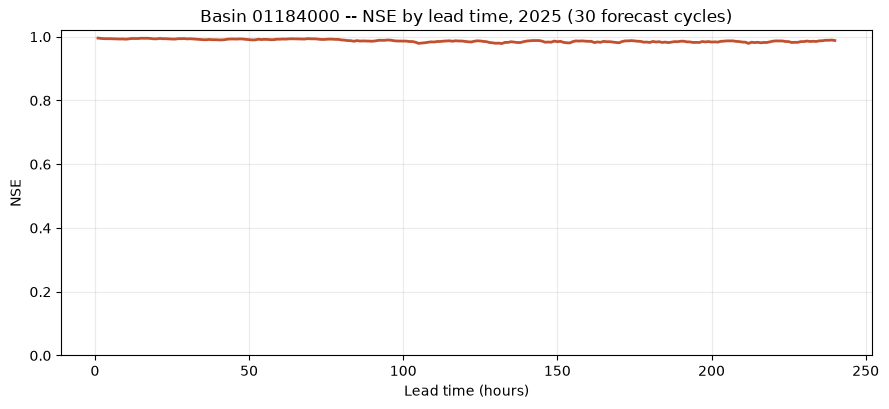

Median NSE across all leads: 0.987  (lead 1h: 0.996, lead 240h: 0.988)


In [4]:
obs_stack = np.stack([r["observed"] for r in runs])
sim_stack = np.stack([r["median"] for r in runs])
lead_h = np.arange(1, HORIZON + 1)
nse_by_lead = np.array([nse(obs_stack[:, h], sim_stack[:, h]) for h in range(HORIZON)])

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(lead_h, nse_by_lead, color="#C1502E", linewidth=2.0)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Lead time (hours)")
ax.set_ylabel("NSE")
ax.set_title(f"Basin {BASIN} -- NSE by lead time, {EVAL_YEAR} ({N_ORIGINS} forecast cycles)")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
print(f"Median NSE across all leads: {np.nanmedian(nse_by_lead):.3f}  "
      f"(lead 1h: {nse_by_lead[0]:.3f}, lead {HORIZON}h: {nse_by_lead[-1]:.3f})")


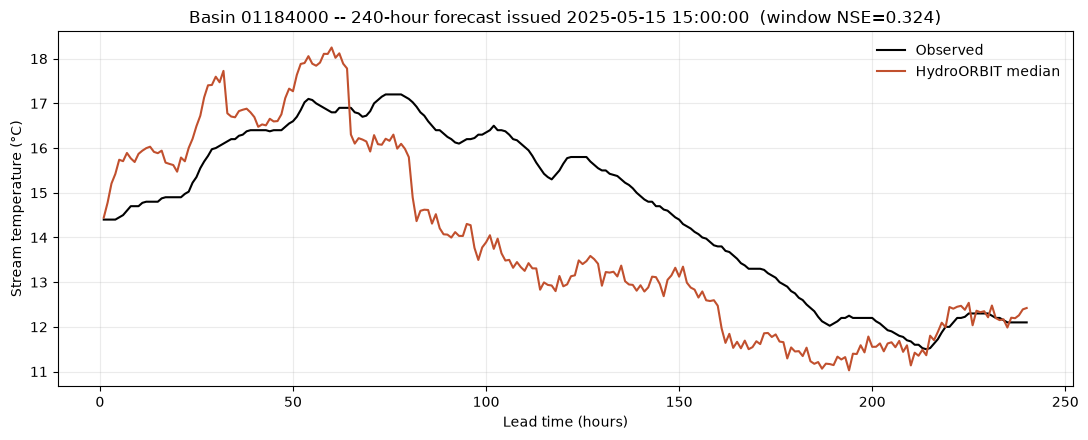

In [5]:
best = max(runs, key=lambda r: np.nanstd(r["observed"]))
best_nse = nse(best["observed"], best["median"])

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(lead_h, best["observed"], color="black", linewidth=1.5, label="Observed")
ax.plot(lead_h, best["median"], color="#C1502E", linewidth=1.5, label="HydroORBIT median")
ax.set_xlabel("Lead time (hours)")
ax.set_ylabel("Stream temperature (\u00b0C)")
ax.set_title(f"Basin {BASIN} -- {HORIZON}-hour forecast issued {best['issue_time']}  (window NSE={best_nse:.3f})")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
